In [1]:
%cd ..
%pwd

/home/cveihmeyer_umass_edu/HeST


'/home/cveihmeyer_umass_edu/HeST'

In [2]:
import os
import sys
import HeST as hest
import HeST.Amherst_split_cpd_with_numba as examp
import numpy as np
import matplotlib.pyplot as plt
import HeST.Detection as detection
from numba import jit
# from tqdm import tqdm
from analysis.analysis_functions import *
import astropy.stats as astat
from scipy.interpolate import interp1d
import pickle
import scipy
import glob
import pandas

In [ ]:
# need to load in the evaporation file (which is a pickle) and make the basic plots


with open('./data/new_batch_pracrice.pkl', 'rb') as f:
    slurm_practice = pickle.load(f)





In [ ]:
plot_hist_flavors(slurm_practice)

In [6]:
refl_prob = np.linspace(0.1, 0.9, 9)
evap_eff = np.linspace(0.1, 0.9, 9)
rr, ee = np.meshgrid(refl_prob, evap_eff)

combinations = np.round(np.column_stack((rr.ravel(), ee.ravel())), 3)

In [ ]:
print(combinations)

In [11]:
# write a file name 
import time 
import os
# this will be used in the saving that we do later, so I should add this line to HeST basic script
name_directory =os.path.join('', time.strftime('%y%m%d', time.gmtime()))

import numpy as np
num_quasiparticles = np.random.randint(low = 10000, high= 60000, size=1000)

with open(os.path.join('parameters', 'sweep_refl_evap.txt'), 'a+') as f:
    for i, (refl, evap) in enumerate(combinations):
        f.write(f'/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/trial_{i}.pkl')
        f.write(' ')
        f.write(f'{refl}')
        f.write(' ')
        for ii in range(3):
            f.write(f'{evap},')
        f.write('\n')


In [ ]:
# the goal of this is to sweep through the files, collect the channel sums, and then move save that and move on. 
import glob
file_list = glob.glob('./data/sample_1000/*')

channel_1 = np.empty(len(file_list))
channel_2 = np.empty(len(file_list))
for i, file in enumerate(file_list):
    with open(file, 'rb') as f:
        evap = pickle.load(f)
        channel_1[i] = len(evap.arrivalTimes_us[0])
        channel_2[i] = len(evap.arrivalTimes_us[1])
np.savetxt('./data/ch1_ch2_comparison/sample_run_data.txt', np.column_stack((channel_1, channel_2)))
config = {}
config['diff_prob'] = 0.8
config['refl_prob'] = 0.3
config['evap_eff'] = 0.6
config['num_qps'] = 10000
with open("config.txt", "w+") as file:
    for key, value in config.items():
        file.write(f"{key}={value}\n")

In [ ]:
fig, ax = plt.subplots(figsize = (6,6))
ax.scatter(channel_1, channel_2)
ax.set_aspect('equal',adjustable= 'box')
ax.set_xlim(0, 8000)
ax.set_ylim(0, 8000)

In [ ]:
templates = np.load('./data/dispersion_curves/templates.npy')
time = np.linspace(0, 10, 25000)
cpd1_scint_template = templates[0]
cpd2_scint_template = templates[1]
cpd1_evap_template = templates[2]
cpd2_evap_template = templates[3]
fig, ax = plt.subplots()
ax.plot(time, cpd1_scint_template, label= 'cpd1 scint')

ax.plot(time, cpd2_scint_template, label = 'cpd2 scint')
ax.plot(time, cpd1_evap_template, label = 'cpd1 evap')
ax.plot(time, cpd2_evap_template, label = 'cpd2 evap')
ax.set_title('Will Template Vs Old Template')
ax.legend()
ax.set_xlim(0, 2.5)

In [ ]:
# sampling rate is 1.25e6 per second: meaning that per each thing has 1/1.25e6 --> 0.8e-6 still the same as before. 
# now we need to save 
upper = int(5 * 2500)
lower = int(1.25*2500)
time = np.linspace(0, 10, 25000)
cpd1_scint_template = templates[0]
cpd2_scint_template = templates[1]
cpd1_evap_template = templates[2]
cpd2_evap_template = templates[3]
fig, ax = plt.subplots()
ax.plot(time[lower:upper], cpd1_scint_template[lower:upper], label= 'cpd1 scint')
ax.plot(time[lower:upper], cpd2_scint_template[lower:upper], label = 'cpd2 scint')
ax.plot(time[lower:upper], cpd1_evap_template[lower:upper], label = 'cpd1 evap')
ax.plot(time[lower:upper], cpd2_evap_template[lower:upper], label = 'cpd2 evap')
ax.set_title('Will Template Vs Old Template')
ax.legend()
ax.set_xlim(0, 2.5)

In [ ]:
print(time[-3] - time[-4])

 # this should be in us I think... 

In [ ]:
# need to load in the evaporation file (which is a pickle) and make the basic plots


with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_z_1.5_test.pkl', 'rb') as f:
    many_qps = pickle.load(f)
plot_hist_flavors(many_qps)
plot_stacked_hist(many_qps)
plot_waveform(many_qps)

In [5]:
time = np.arange(0, 9999 * 0.8e-6, 0.8e-6)

In [ ]:
cpd1_hits = np.histogram(many_qps.arrivalTimes_us[0], bins=3750, range = [0,3000])[0] * 10e-3
cpd2_hits = np.histogram(many_qps.arrivalTimes_us[1], bins=3750, range = [0,3000])[0] * 10e-3
plt.plot(time, np.convolve(cpd1_hits, cpd1_template))

plt.xlabel('Seconds')
plt.ylabel('Energy')
plt.title('CPD 1 pulse comparison')

In [ ]:
s1, s2, time = generate_waveform(many_qps)
plt.plot(time, s1)

In [ ]:
plt.hist(many_qps.arrivalTimes_us[0], bins=200, range = [0,3000])

In [ ]:
# I want to read these in by height, and then I can move from there
h_10_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_10_*.pkl')
h_15_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_15_*.pkl')
h_5_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_5_*.pkl')
h_2_5_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h_2.5_*.pkl')
print(h_15_files)

In [ ]:
extract_pulse(h_15_files[:3])

In [ ]:
extract_pulse(['/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/Test_2.pkl'])

In [ ]:
hex_colors = [
    "#FF5733", "#33FF57", "#3357FF", "#FF33A1", "#000000",
    "#33FFFF", "#A133FF", "#FF8C33", "#57FF33", "#FF3333",
    "#1E90FF", "#FFD700"  # Added Dodger Blue and Gold
]

markers = ["o", "s", "^", "v", "D", "X", "P", "*", "H", "<"]

all_files = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/sweep_2d/h*.pkl')
names = []
waveforms = []
fig, ax = plt.subplots(figsize=(16, 8))
for ii, f in enumerate(all_files):
    print(f)
    with open(f, 'rb') as file:
        evap = pickle.load(file)
    name = f.split('/')[-1][:-4]
    names.append(name)
    s1, s2, time = generate_waveform(evap)
    waveforms.append([s1, s2])
    ax.scatter(time, s1, color=hex_colors[ii],s=10 ,label=name + ' CPD1',  alpha=0.1 ) 
    # ax.plot(time, s1, label=name + ' CPD2') 


ax.legend()

    
    


In [ ]:
fig, ax = plt.subplots()
ax.plot(time[lower:upper] - 0.001, 88 * cpd1_evap_template[lower:upper] / 1921619327.2159166, label = 'cpd1 evap')

In [ ]:
file = all_files[0]
print(file.split('/'))
name = file.split('/')[-1]
print(name[:-4])

In [ ]:
# for each, I want to store the cpd time arrays, so we need a 3D thing

def extract_pulse(file_list):
    heights = []
    for ii, file in enumerate(file_list):
        with open(file, 'rb') as f:
            height = pickle.load(f)
        
        plot_stacked_hist(height, title=file_list[ii][-14:-4])
        plot_hist_flavors(height,title=file_list[ii][-14:-4] )
        cpd1 = height.arrivalTimes_us[0]
        cpd2 = height.arrivalTimes_us[1]
        heights.append(cpd1)
        heights.append(cpd2)
    return heights

h_15 = extract_pulse(h_15_files)

In [ ]:
plt.title(str(h_15_files[0])[-14:-4])
plt.hist(h_15[0], bins=200, range = (0,3000))

In [12]:
templates = np.load('./data/dispersion_curves/templates.npy')
time = np.linspace(0, 0.01, 25000)
cpd1_scint_template = templates[0]
cpd2_scint_template = templates[1]
cpd1_evap_template = templates[2]
cpd2_evap_template = templates[3]

In [ ]:
with open('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/Test.pkl', 'rb') as f:
    evap = pickle.load(f)
# plot_stacked_hist(evap)
# plot_hist_flavors(evap)
plot_waveform(evap)
plt.plot(time - 0.0011, 110 * cpd2_evap_template)

In [ ]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/*.pkl')
for ii, f in enumerate(file_list):
    if ii%2==0 or ii%5==0:
        continue
    print(f)
    title = f.split('/')[-1][:-4]
    with open(f, 'rb') as file:
        evap = pickle.load(file)
    
    plot_hist_flavors(evap, title = title)
    if ii>50:
        break

In [5]:
trial_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/trial_*.pkl')
config_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/config_*.csv')

In [6]:
import re

def extract_number(filename, prefix, delimiter):
    match = re.search(rf"{prefix}_(\d+)\.{delimiter}", filename)
    return int(match.group(1)) if match else None

# Create a dictionary mapping numbers to file paths
config_map = {extract_number(f, "config", 'csv'): f for f in config_list}
print(config_map)
trial_map = {extract_number(f, "trial", 'pkl'): f for f in trial_list}
print(trial_map)


# Match based on extracted numbers
matched_pairs = {num: (config_map.get(num), trial_map.get(num)) for num in set(config_map) & set(trial_map)}

for num, (config, trial) in matched_pairs.items():
    print(f"Config: {config} <--> Trial: {trial}")

{1: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/config_1.csv', 10: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/config_10.csv', 11: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/config_11.csv', 12: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/config_12.csv', 13: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/config_13.csv', 14: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/config_14.csv', 15: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/config_15.csv', 16: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/config_16.csv', 17: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_refl_evap/config_17.csv', 18: '/work/pi_sherte

In [28]:
trial_map.get(3)

In [ ]:
extract_pulse(file_list=file_list[:3])

In [ ]:
fig, ax = plt.subplots()
with open(file_list[0], 'rb') as f:
    evap = pickle.load(f)
s1, s2, time =generate_waveform(evap)
ax.plot(time, s1, label='CPD1')
ax.plot(time, s2, label='CPD2')

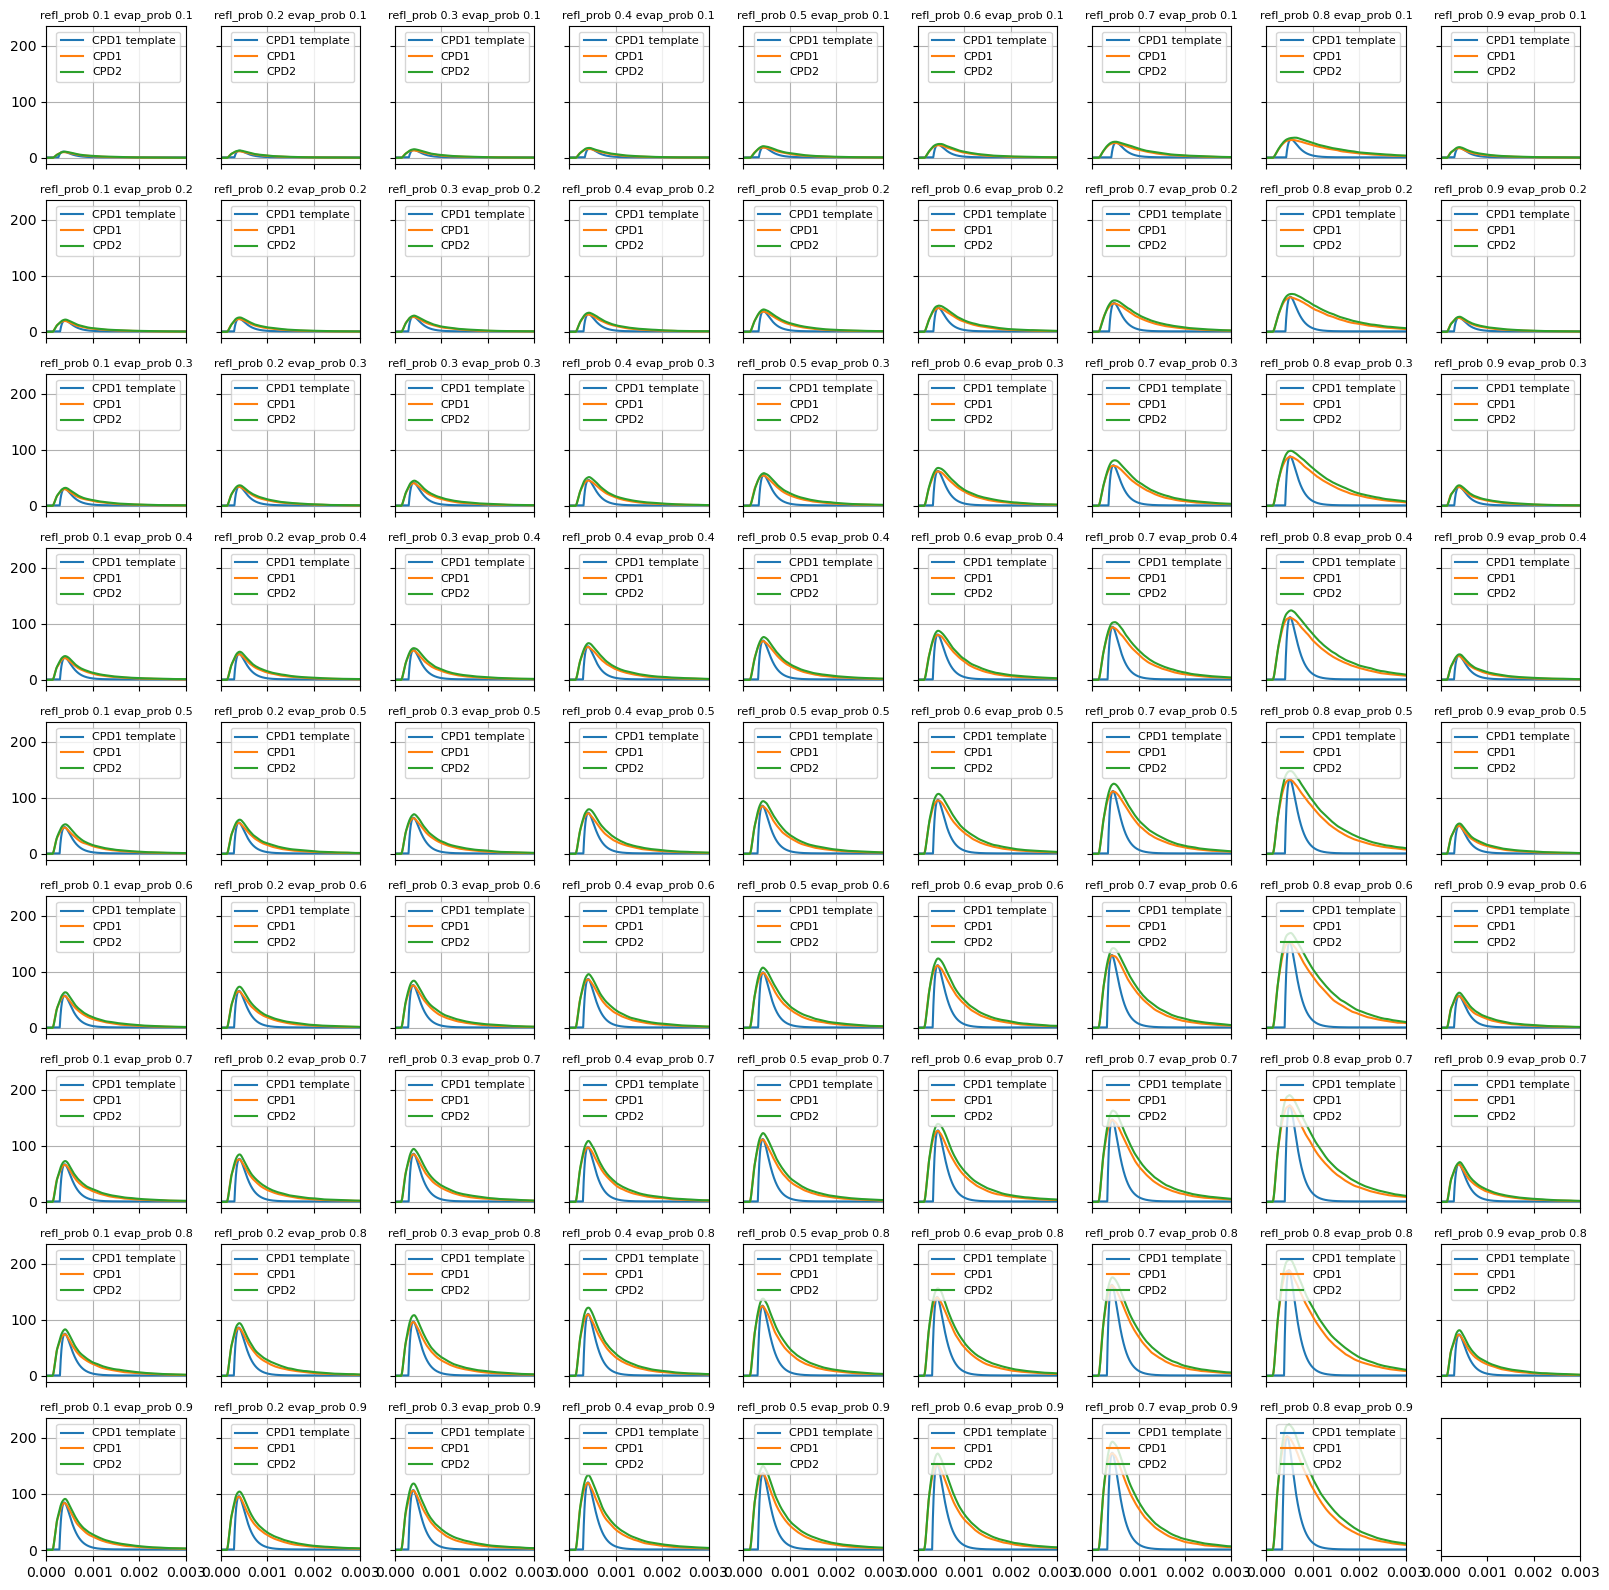

In [7]:
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]

least_squares = np.empty((len(config_list)))
fig, axs = plt.subplots(9, 9, figsize = (16,16), sharex=True, sharey=True)
ax = axs.flatten()
i = 0
for num, (config, trial) in matched_pairs.items():
    with open(trial, 'rb') as file:
        evap = pickle.load(file)   
    config = pandas.read_csv(config)
    refl_prob = str(config['refl_prob'][0])
    evap_prob = str(config['evap_eff'][0])
    title =  'refl_prob ' + refl_prob + ' evap_prob ' + evap_prob
    s1, s2 , time =generate_waveform(evap)

    peak = np.max(s1)
    peak_index_signal = np.argmax(s1)
    peak_index_template = np.argmax(template_1)
    diff = peak_index_signal - peak_index_template
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak
    least_squares[i] = np.sum(s1**2 - new_template**2)
    ax[i].plot(time, new_template + 1, label = 'CPD1 template')
    ax[i].plot(time, s1, label='CPD1')
    ax[i].plot(time, s2, label='CPD2')
    ax[i].set_title('refl_prob ' + refl_prob + ' evap_prob ' + evap_prob, fontsize=8)
    ax[i].legend(loc='upper right', fontsize=8)
    ax[i].grid()
    ax[i].set_xlim(0, 0.003)
    i += 1
fig.tight_layout()
fig.savefig('sweep_2d_refl_evap.png', dpi=300)


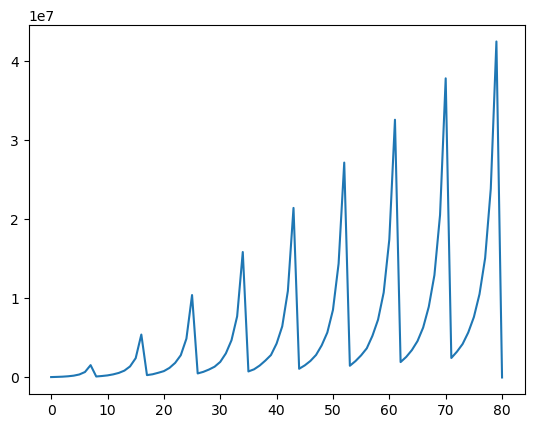

In [8]:
plt.plot(least_squares)

In [3]:
trial_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/trial_*.pkl')
config_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/config_*.csv')
matched_pairs = get_file_map(config_list=config_list, trial_list=trial_list)

{1: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/config_1.csv', 10: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/config_10.csv', 100: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/config_100.csv', 101: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/config_101.csv', 102: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/config_102.csv', 103: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/config_103.csv', 104: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/config_104.csv', 105: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/config_105.csv', 106: '/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/config_106.csv', 107: '/work/pi_

[array([1069.29088222,  191.50657856, 1916.96183585, ..., 2037.19086516,
         388.8080671 , 1052.28457001]),
 array([ 665.73143735,  670.92858573,  341.98307283, ...,  518.97665504,
        1429.48843828, 2071.40580474]),
 array([ 247.93353236,  695.41027798,  133.83636413, ...,  304.3547211 ,
        1528.71630793,  748.37991227]),
 array([ 3310.58538091, 17805.60652028,  4083.00237868, ...,
         2147.75275018,   537.15676327,   688.32622881]),
 array([  349.55879261,   285.45943637, 16400.55545938, ...,
          366.95716744,   158.46998411,   157.69881364]),
 array([ 351.21872814,  178.38539671,  248.97860882, ..., 3184.89543373,
         430.11833159, 1035.84170811])]

<Figure size 640x480 with 0 Axes>

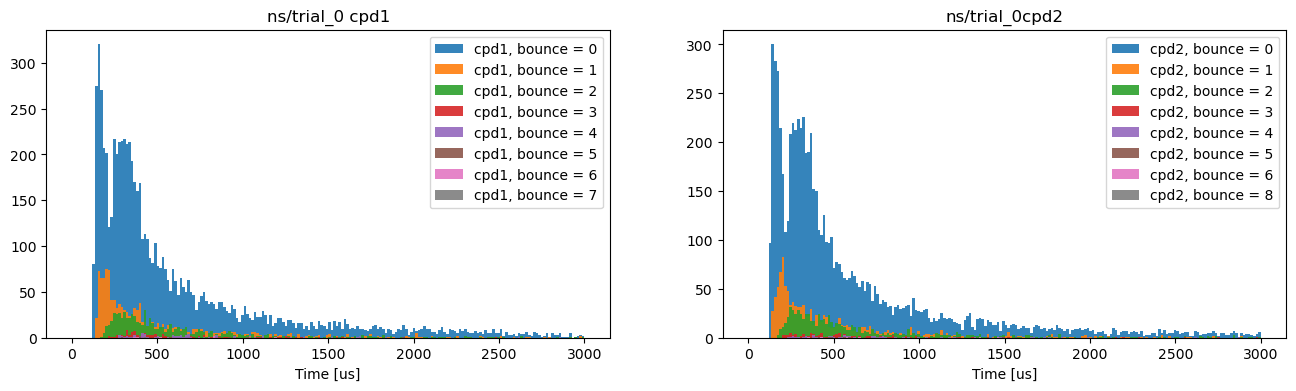

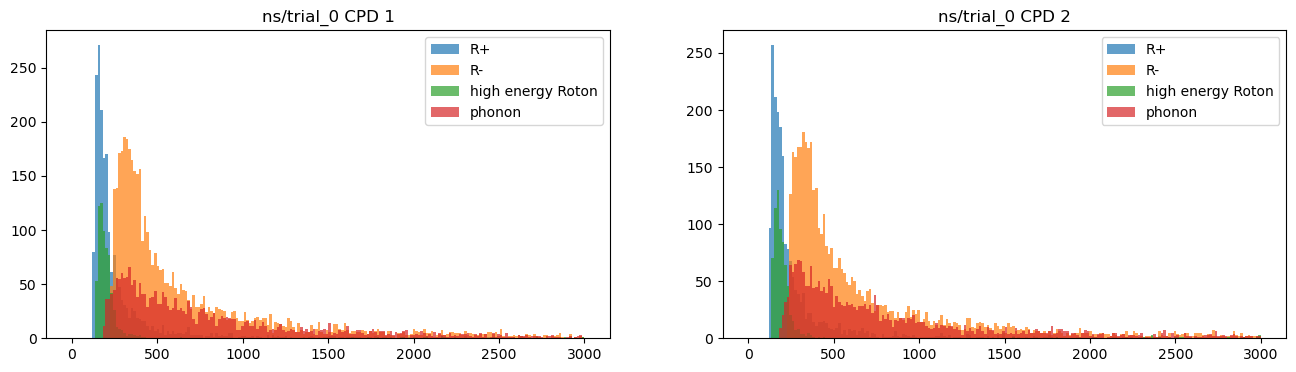

<Figure size 640x480 with 0 Axes>

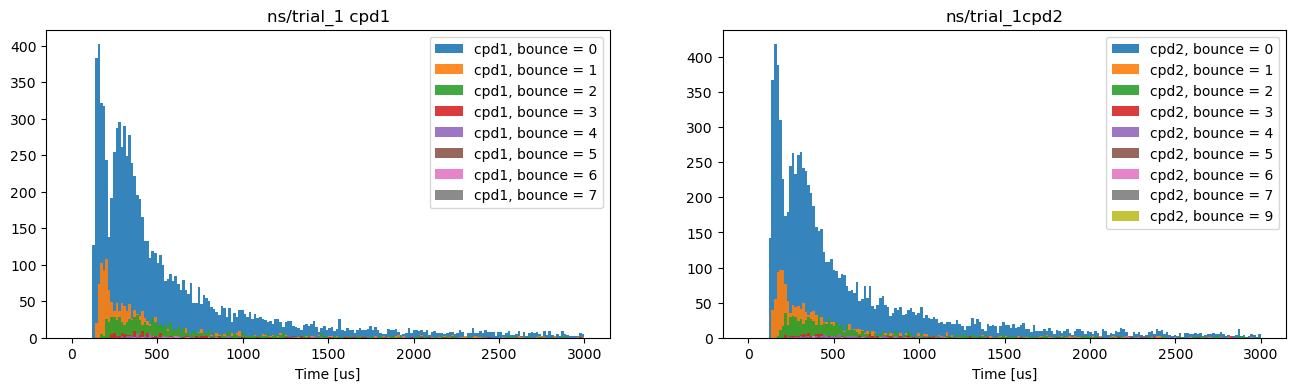

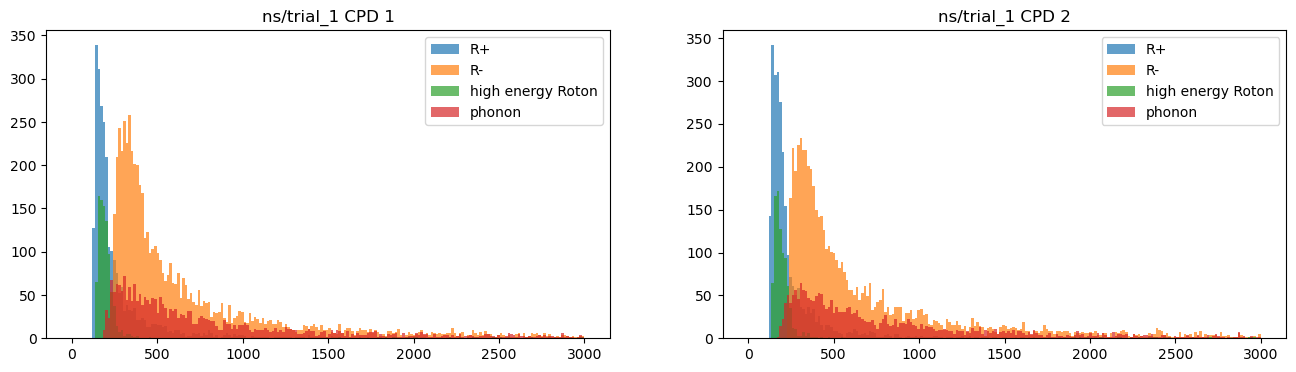

<Figure size 640x480 with 0 Axes>

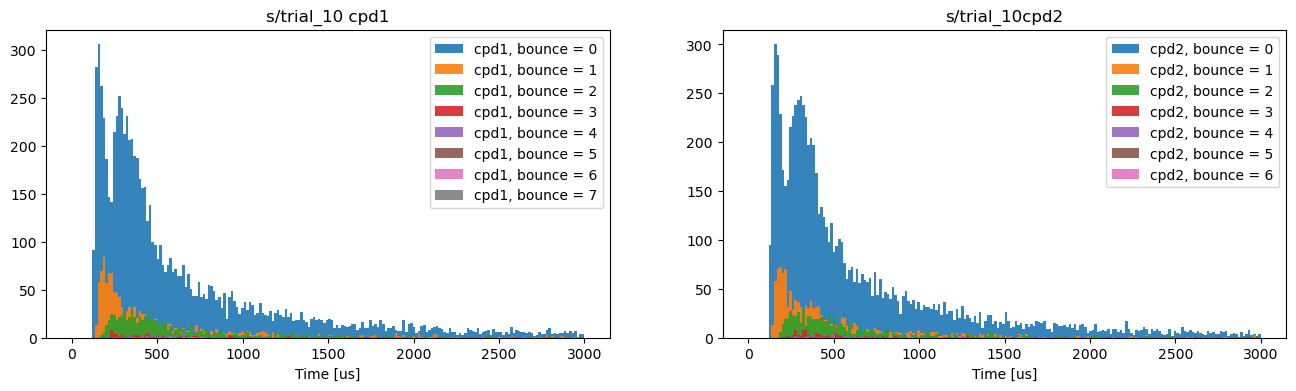

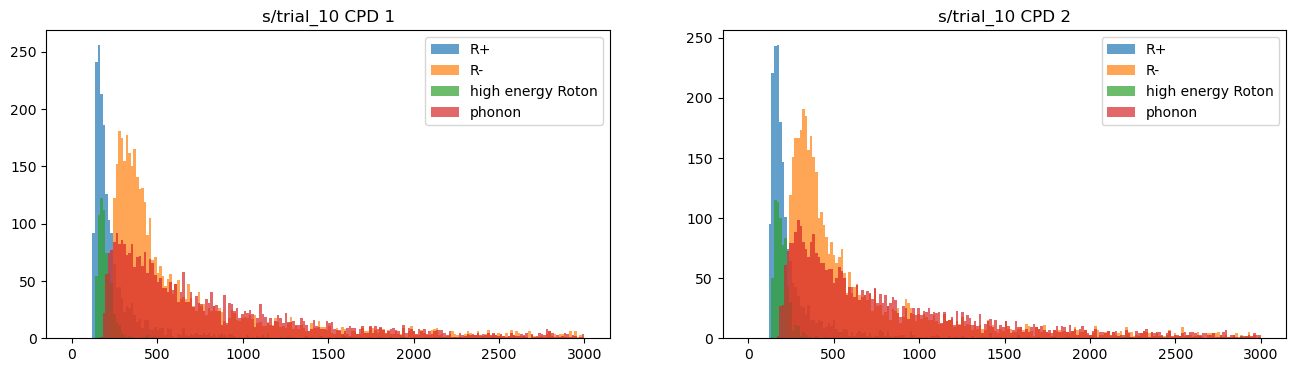

In [5]:
extract_pulse(trial_list[0:3])

IndexError: index 100 is out of bounds for axis 0 with size 100

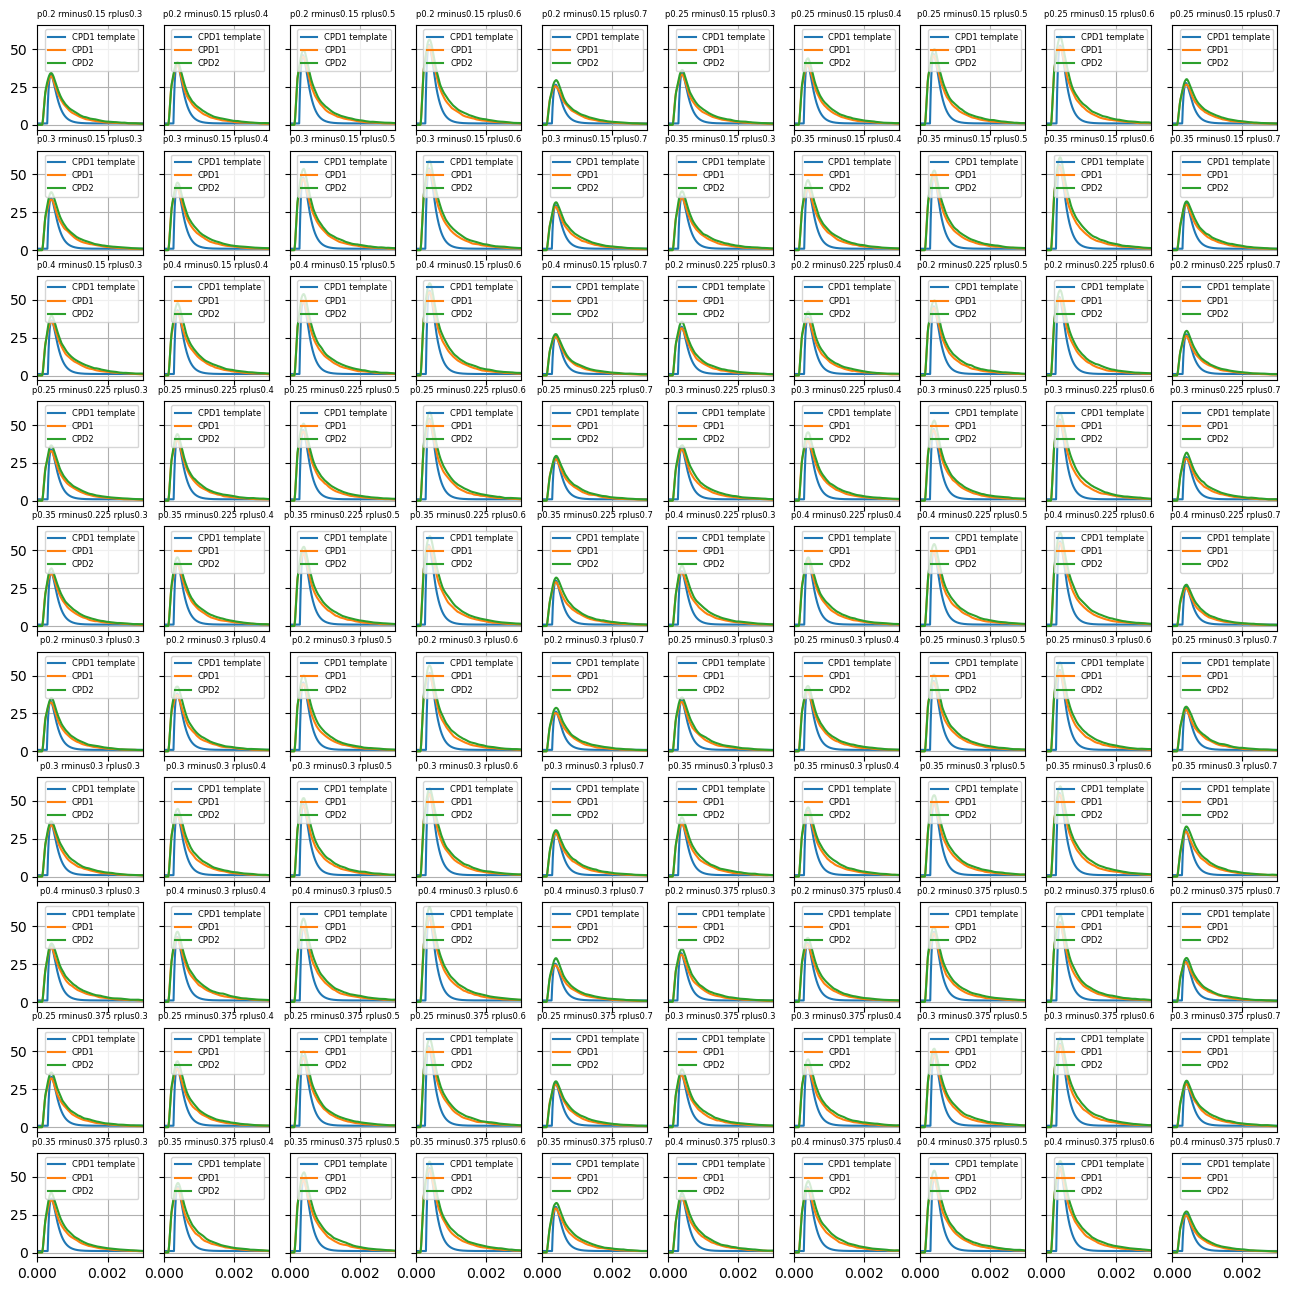

In [4]:
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]

least_squares = np.empty((len(config_list)))
fig, axs = plt.subplots(10, 10, figsize = (16,16), sharex=True, sharey=True)
ax = axs.flatten()
i = 0
for num, (config, trial) in matched_pairs.items():
    with open(trial, 'rb') as file:
        evap = pickle.load(file)   
    config = pandas.read_csv(config)
    phonon = str(config['evap_eff'][0])
    rminus = str(config['evap_eff'][1])
    rplus = str(config['evap_eff'][2])
    title = 'p' + phonon +' rminus' + rminus + ' rplus' + rplus
    s1, s2 , time =generate_waveform(evap)

    peak = np.max(s1)
    peak_index_signal = np.argmax(s1)
    peak_index_template = np.argmax(template_1)
    diff = peak_index_signal - peak_index_template
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak
    least_squares[i] = np.sum(s1**2 - new_template**2)
    ax[i].plot(time, new_template + 1, label = 'CPD1 template')
    ax[i].plot(time, s1, label='CPD1')
    ax[i].plot(time, s2, label='CPD2')
    ax[i].set_title(title, fontsize=6)
    ax[i].legend(loc='upper right', fontsize=6)
    ax[i].grid()
    ax[i].set_xlim(0, 0.003)
    i += 1
fig.tight_layout()

In [4]:
def formulate_template(s1, template_1):
    peak = np.max(s1)
    peak_index_signal = np.argmax(s1)
    peak_index_template = np.argmax(template_1)
    diff = peak_index_signal - peak_index_template
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak
    return new_template

In [ ]:
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]

least_squares = np.empty((len(config_list)))
fig, axs = plt.subplots(10, 10, figsize = (16,16), sharex=True, sharey=True)
ax = axs.flatten()
i = 0
for num, (config, trial) in matched_pairs.items():
    with open(trial, 'rb') as file:
        evap = pickle.load(file)   
    config = pandas.read_csv(config)
    phonon = str(config['evap_eff'][0])
    rminus = str(config['evap_eff'][1])
    rplus = str(config['evap_eff'][2])
    title = 'p' + phonon +' rminus' + rminus + ' rplus' + rplus
    s1, s2 , time =generate_waveform(evap)
    new_template = formulate_template(s1, template_1)

    fs = evap.flavor
    for value in np.unique(fs[0]):
        mask = (fs[0] == value)
        ax[i].hist(evap.arrivalTimes_us[0][mask], bins = 200, range = [0,3000], alpha= 0.7,stacked=True, label = value)


    # ax[i].plot(time, new_template + 1, label = 'CPD1 template')
    ax[i].set_title(title, fontsize=6)
    ax[i].legend(loc='upper right', fontsize=6)
    ax[i].grid()
    ax[i].set_xlim(0, 3000)
    i += 1
    if i > 99:
        break
fig.tight_layout()

(0.0, 100.0)

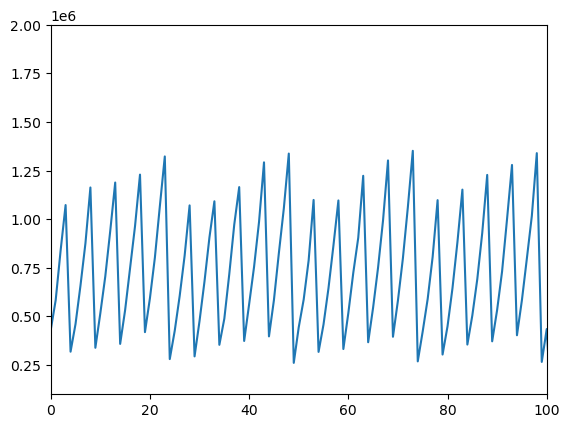

In [6]:
plt.plot(least_squares)
plt.ylim(1e5, 2e6)
plt.xlim(0, 100)

# Understanding Optimal Momentum evaporation efficiency. 


In [ ]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/*.pkl')
extract_pulse(file_list[:3])


In [ ]:
file_list = glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/*.pkl')
config_list= glob.glob('/work/pi_shertel_umass_edu/quasiparticle_simulation/waveform_comparison/sweep_mom_bins/*.csv')
fig, axs = plt.subplots(9, 3, figsize = (16,16), sharex=True, sharey=True)
ax = axs.flatten()
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]
chi_squared = np.empty_like(file_list, dtype=float)

for i, f1 in enumerate(file_list):

    with open(f1, 'rb') as file:
        evap = pickle.load(file)
    config_file = pandas.read_csv(config_list[i])
    s1, s2 , time =generate_waveform(evap)
    peak = np.max(s1)
    peak_index_signal = np.argmax(s1)
    peak_index_template = np.argmax(template_1)
    diff = peak_index_signal - peak_index_template
    before_pad = int(diff)
    after_pad = len(s1) - len(template_1) -before_pad
    new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)  * peak

    chi_squared[i] = np.sum((s1+1)**2 - (new_template+1)**2/(new_template+1))
    ax[i].plot(time, new_template + 1, label = 'CPD1 template')

    ax[i].plot(time, s1 + 1, label='CPD1')
    ax[i].set_xlim(0, 0.003)
    ax[i].plot(time, s2, label='CPD2')
    ax[i].set_xlim(0, 0.003)
    eff = config_file['evap_eff'].astype('str')
    title = 'p='+ eff[0] + ' ,r-=' + eff[1] + ' ,r+= ' + eff[2]
    ax[i].set_title(title)
    ax[i].legend()
    ax[i].grid()
fig.tight_layout()
 

In [ ]:
np.min(chi_squared)

In [ ]:
config_file = pandas.read_csv(config_list[1])
evap = config_file['evap_eff'].astype('str')
evap[:]

In [24]:
def compare_waveforms(evap):
    template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
    template_1 = template[0]
    template_2 = template[1]
    s1, s2, time = generate_waveform(evap)
    if len(template_1) > len(s1):
        diff = len(template_1) - len(s1)
        mins_1 = np.empty((diff))
        mins_2 = np.empty((diff))
        for i in range(diff):
            mins_1[i] = scipy.stats.chisquare(template_1[i:diff-i], s1)
            # mins[i] = scipy.stats.chisquare(template[i:diff])
    if len(template_1) < len(s1):
        diff = len(s1) - len(template_1)

        mins_1 = np.empty((diff))
        mins_2 = np.empty((diff))
        for i in range(diff):
            print(np.shape(template_1[i:diff-i]))
            print(np.shape(s1[i:diff-i]))

            mins_1[i] = scipy.stats.chisquare(s1[i:diff-i], template_1)
            # mins[i] = scipy.stats.chisquare(template[i:diff])
    return np.min(mins_1) 

In [ ]:
s1, s2, time = generate_waveform(many_qps)
template = np.load('/home/cveihmeyer_umass_edu/HeST/data/dispersion_curves/shortened_template.npy')
template_1 = template[2]
template_2 = template[3]
print(np.shape(s1))
print(np.shape(template_1))

diff = len(s1) - len(template_1)

peak = np.max(s1)
mins_1 = np.empty((diff))
mins_2 = np.empty((diff))
for i in range(diff):
    try:
        mins_1[i] = scipy.stats.chisquare(s1[i:len(template_1)+i],peak* template_1)
        print('it worked!')
    except ValueError:
        continue



In [ ]:
print(mins_1)

In [ ]:

plt.plot(time, s1)
time_2 = np.linspace(0, 0.005, int(9375))

plt.plot(time_2, peak * template_1)

In [ ]:
peak_index_signal = np.argmax(s1)
peak_index_template = np.argmax(template_1)
diff = peak_index_signal - peak_index_template
before_pad = int(diff)
before_pad = np.nonzero(s1)[0][0]
after_pad = len(s1) - len(template_1) -before_pad

new_template = np.pad(template_1, (before_pad, after_pad), mode='constant', constant_values=0)

plt.plot(time, s1)
plt.plot(time, peak * new_template)
scipy.stats.chisquare(s1, peak * new_template)